In [ ]:
'''# Model Interpretation
This notebook explains which features contribute most to the fraud detection model's predictions.
The analysis focuses on the final Random Forest model selected for further use.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


'''amount_to_origin_balance          0.435089
   oldbalanceOrg                     0.138934
   amount_to_destination_balance     0.072411
   amount                            0.070523
   type_CASH_OUT                     0.060020
   type_PAYMENT                      0.056881
   log_amount                        0.054064
   type_CASH_IN                      0.045393
   type_TRANSFER                     0.043770
   oldbalanceDest                    0.016539
   step                              0.005769
   type_DEBIT                        0.000607'''

'''Feature importance does NOT mean:
"This feature causes fraud."
It means approximately:
"The Random Forest relied heavily on this feature when making its tree-based decisions."
That distinction is important in an interview.'''

In [ ]:
#Create the feature-importance table

feature_importance = pd.DataFrame({
    "Feature": [
        "amount_to_origin_balance",
        "oldbalanceOrg",
        "amount_to_destination_balance",
        "amount",
        "type_CASH_OUT",
        "type_PAYMENT",
        "log_amount",
        "type_CASH_IN",
        "type_TRANSFER",
        "oldbalanceDest",
        "step",
        "type_DEBIT"
    ],
    "Importance": [
        0.435089,
        0.138934,
        0.072411,
        0.070523,
        0.060020,
        0.056881,
        0.054064,
        0.045393,
        0.043770,
        0.016539,
        0.005769,
        0.000607
    ]
})

feature_importance

,Feature,Importance
0,amount_to_origin_balance,0.435089
1,oldbalanceOrg,0.138934
2,amount_to_destination_balance,0.072411
3,amount,0.070523
4,type_CASH_OUT,0.060020
5,type_PAYMENT,0.056881
6,log_amount,0.054064
7,type_CASH_IN,0.045393
8,type_TRANSFER,0.043770
9,oldbalanceDest,0.016539


In [3]:
#Sort the features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,amount_to_origin_balance,0.435089
1,oldbalanceOrg,0.138934
2,amount_to_destination_balance,0.072411
3,amount,0.070523
4,type_CASH_OUT,0.060020
5,type_PAYMENT,0.056881
6,log_amount,0.054064
7,type_CASH_IN,0.045393
8,type_TRANSFER,0.043770
9,oldbalanceDest,0.016539


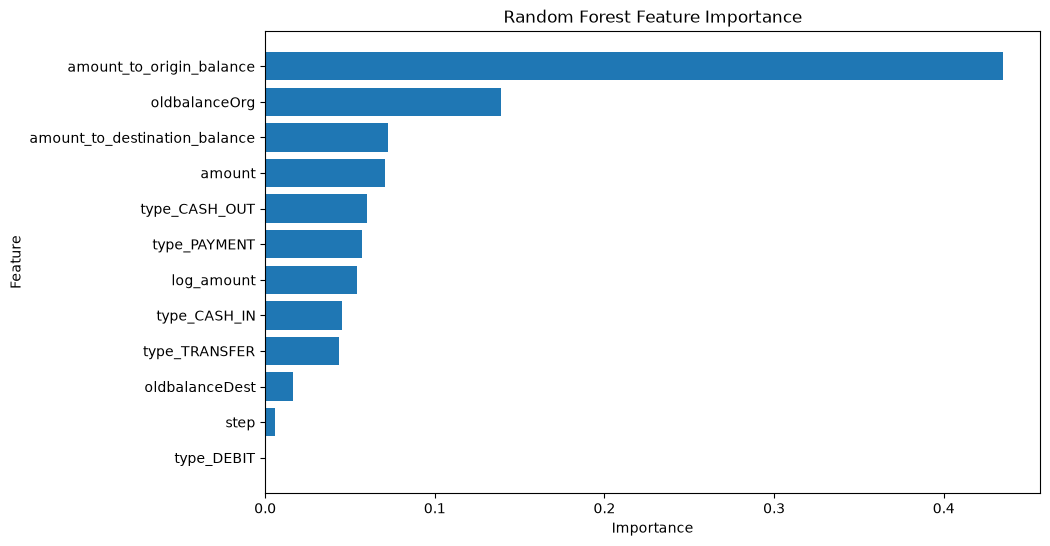

In [4]:
#Create the feature-importance chart
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
'''What your chart tells us
The Random Forest relied most heavily on:

amount_to_origin_balance → ~43.5%
oldbalanceOrg → ~13.9%
amount_to_destination_balance → ~7.2%
amount → ~7.1%
type_CASH_OUT → ~6.0%

The first feature is much larger than the others, so we should investigate it.

But remember
43.5% importance does not mean:
43.5% of fraud is caused by this feature.
It means the Random Forest's splitting decisions relied heavily on this feature.'''

In [ ]:
'''amount_to_origin_balance :
X["amount_to_origin_balance"] = (
    X["amount"] / (X["oldbalanceOrg"] + 1)
)

In simple words:
transaction amount ÷ sender's balance before transaction

For example:
amount = 900
oldbalanceOrg = 1000

900 / (1000 + 1)
≈ 0.899

So the transaction amount is roughly 90% of the sender's previous balance.

Now let's see whether this ratio behaves differently for normal vs fraud transactions.
'''

In [7]:
import pandas as pd
import numpy as np

file_path = "../data/raw/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(file_path)

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print(X.shape)
print(y.shape)


(6362620, 10)
(6362620,)


In [8]:
features_to_drop = [
    "nameOrig",
    "nameDest",
    "newbalanceOrig",
    "newbalanceDest",
    "isFlaggedFraud"
]

X = X.drop(columns=features_to_drop)

X = pd.get_dummies(
    X,
    columns=["type"],
    dtype=int
)

X["amount_to_origin_balance"] = (
    X["amount"] / (X["oldbalanceOrg"] + 1)
)

X["amount_to_destination_balance"] = (
    X["amount"] / (X["oldbalanceDest"] + 1)
)

X["log_amount"] = np.log1p(X["amount"])

print(X.shape)

(6362620, 12)


In [9]:
df_analysis = pd.DataFrame({
    "amount_to_origin_balance": X["amount_to_origin_balance"],
    "isFraud": y
})

df_analysis.groupby("isFraud")["amount_to_origin_balance"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,70764.320934,508745.258992,1.765481e-08,0.233401,6.511566,12355.590000,92445516.64
1,8213.0,1161.966671,32297.153000,0.000000e+00,0.999991,0.999998,0.999999,1933920.80


In [10]:
fraud_ratio = (
    df_analysis[df_analysis["isFraud"] == 1]
    ["amount_to_origin_balance"]
)

for threshold in [0.99, 0.999, 0.9999]:
    count = (fraud_ratio >= threshold).sum()
    percentage = count / len(fraud_ratio) * 100

    print(
        f"Ratio >= {threshold}: "
        f"{count} fraud transactions "
        f"({percentage:.2f}%)"
    )

Ratio >= 0.99: 8045 fraud transactions (97.95%)
Ratio >= 0.999: 8005 fraud transactions (97.47%)
Ratio >= 0.9999: 7785 fraud transactions (94.79%)


In [ ]:
'''### Interpretation of amount_to_origin_balance

The feature `amount_to_origin_balance` was the most important feature
according to the Random Forest feature importance analysis.

Further analysis showed that 8,045 out of 8,213 fraudulent transactions
(97.95%) had a value greater than or equal to 0.99.

This indicates that the feature is highly discriminative in the PaySim
dataset. However, this relationship should not be interpreted as causal,
and the unusually strong pattern may be specific to the synthetic dataset.'''

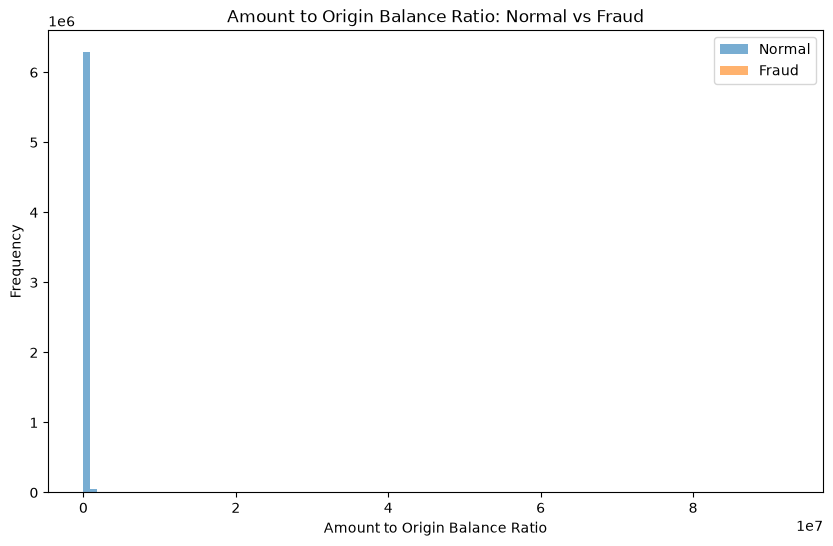

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_analysis[df_analysis["isFraud"] == 0]["amount_to_origin_balance"],
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    df_analysis[df_analysis["isFraud"] == 1]["amount_to_origin_balance"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Amount to Origin Balance Ratio")
plt.ylabel("Frequency")
plt.title("Amount to Origin Balance Ratio: Normal vs Fraud")
plt.legend()

plt.show()

In [ ]:
'''Why the chart looks like this

Look at the x-axis:

0
2 × 10⁷
4 × 10⁷
...

There are some normal transactions with extremely large ratios, up to:

92,445,516.64

Those extreme values stretch the x-axis 
so much that the fraud distribution around 1.0 gets compressed into the left side.

That's why you can barely see the orange fraud bars.

We should NOT delete those values

They are real values in the dataset. Instead, for visualization only,
 we'll focus on the range where the important fraud pattern occurs.'''

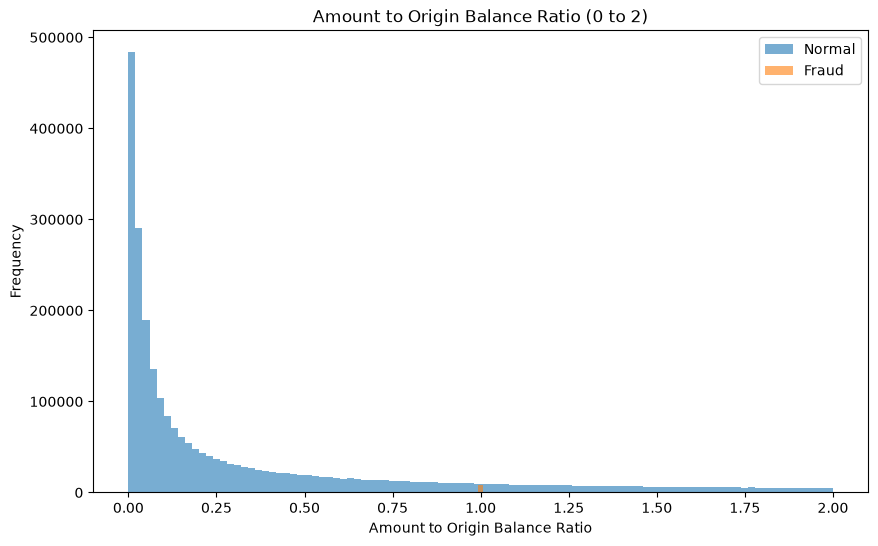

In [12]:
plt.figure(figsize=(10, 6))

normal_ratio = df_analysis[
    df_analysis["isFraud"] == 0
]["amount_to_origin_balance"]

fraud_ratio = df_analysis[
    df_analysis["isFraud"] == 1
]["amount_to_origin_balance"]

plt.hist(
    normal_ratio[normal_ratio <= 2],
    bins=100,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    fraud_ratio[fraud_ratio <= 2],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xlabel("Amount to Origin Balance Ratio")
plt.ylabel("Frequency")
plt.title("Amount to Origin Balance Ratio (0 to 2)")
plt.legend()

plt.show()

In [13]:
df_analysis = pd.DataFrame({
    "oldbalanceOrg": df["oldbalanceOrg"],
    "isFraud": y
})

df_analysis.groupby("isFraud")["oldbalanceOrg"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,8.328287e+05,2.887144e+06,0.0,0.00,14069.00,106969.50,43818855.30
1,8213.0,1.649668e+06,3.547719e+06,0.0,125822.44,438983.45,1517771.48,59585040.37


In [ ]:
'''Good. This result gives us another useful finding.
oldbalanceOrg — sender's balance before the transaction
Compare the two groups:

Statistic	Normal	Fraud
Mean	₹832,829	₹1,649,668
Median	₹14,069	₹438,983
75th percentile	₹106,970	₹1,517,771
Maximum	₹43.82M	₹59.59M
What does this tell us?

The fraudulent transactions generally involve higher sender balances before the transaction.
The median is particularly noticeable:

Normal → ₹14,069
Fraud  → ₹438,983
So the typical fraudulent transaction in this dataset has a much higher oldbalanceOrg than the typical normal transaction.

This helps explain why:
oldbalanceOrg
is the second-most important feature in our Random Forest.
But notice something important
There is still overlap.

For example:
Normal minimum = 0
Fraud minimum  = 0
and both groups have very large maximum values.

Therefore:
oldbalanceOrg alone cannot determine whether a transaction is fraud.
The Random Forest combines it with other features such as:
amount_to_origin_balance
amount_to_destination_balance
amount
transaction type
log_amount
Notebook 07 conclusion so far

We have investigated the top two features:
1. amount_to_origin_balance → ~43.5%
2. oldbalanceOrg            → ~13.9%

And we have evidence explaining why both are useful.
Next we'll investigate amount_to_destination_balance, the third-most important feature.'''

In [ ]:
'''Investigate amount_to_destination_balance
This was our third-most important feature (~7.24%).'''

df_analysis = pd.DataFrame({
    "amount_to_destination_balance": X["amount_to_destination_balance"],
    "isFraud": y
})

df_analysis.groupby(
    "isFraud"
)["amount_to_destination_balance"].describe()

'''amount_to_destination_balance :
| Statistic | Normal |          Fraud |
| --------- | -----: | -------------: |
| Mean      | 26,666 |    **969,883** |
| Median    |  0.915 | **116,419.58** |
| 75%       |  9,698 | **799,123.57** |
| Maximum   | 60.97M |            10M |

The most interesting difference

Median:

Normal → 0.915
Fraud  → 116,419.58

That's a huge difference.
So this feature provides the Random Forest with 
another strong signal separating the two classes.
'''

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,26666.308288,1.690705e+05,1.499039e-08,0.160445,0.915134,9698.21,60965275.64
1,8213.0,969883.436947,2.087282e+06,0.000000e+00,4.368003,116419.580000,799123.57,10000000.00


In [ ]:
''' 